<a href="https://colab.research.google.com/github/jeolin/BCCE_Experiment/blob/main/copper_sulfate_spectral_curve.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Learning Objectives

By working through this notebook, you will be able to:

1.  **Locate and change variables** within pre-written Python code to manipulate experimental parameters.
2.  **Approximate the shape of a typical absorbance spectrum** and understand its key features.
3.  **Identify the absorbance maximum ($\lambda_{max}$)** for various chemical compounds and understand its significance.
4.  **Draw the absorbance spectra of mixtures** of light-absorbing compounds, gaining insight into how multiple components contribute to an overall spectrum.
5.  **Visualize the effect of concentration** on absorbance spectra (coming soon).
6.  **Apply Beer-Lambert Law** principles to quantify concentrations from absorbance data (coming soon).

## Intro 1: Introduction to Python Basics

Welcome to your first steps in Python! This notebook will guide you through some fundamental concepts:

### 1. Variables

In Python, a **variable** is like a container for storing information. You give it a name, and then you can store different types of data inside it, such as numbers, text, or lists of items. Think of it like a labeled box where you can put things.

**Example:**
```python
my_number = 10
my_text = "Hello, Python!"
```
Here, `my_number` is a variable holding the number `10`, and `my_text` is a variable holding the string `"Hello, Python!"`.

### 2. Editing Variable Values

You can change the value stored in a variable at any point after it's been created. Simply assign a new value to the same variable name.

**Example:**
```python
# Initial value
score = 0
print(score) # Output: 0

# Update the value
score = 100
print(score) # Output: 100
```

### 3. Executing Code Cells

In this environment (Colab), your code is organized into **cells**. To see the effects of your code, especially when you change variable values, you need to **execute** the cell. Here's how:

*   **Run a cell:** Click the "Play" button (▶) to the left of the cell.
*   **Keyboard Shortcut:** Select the cell and press `Shift + Enter`.

When a cell executes, Python runs all the code within it from top to bottom. If you modify a variable's value in one cell, you'll need to re-run that cell (and any subsequent cells that depend on that variable) to see the updated results.

Let's start exploring!

## Intro 2: Chemical Compounds for Spectroscopic Study

Here are five chemical compounds that exhibit distinct absorption maxima ($\lambda_{max}$) within the visible light spectrum. These choices are designed to provide a range of colors and absorption profiles for your experiments.

Visible light ranges approximately from 380 nm (violet) to 750 nm (red).

1.  **Tartrazine (Yellow Food Dye)**
    *   **Approximate $\lambda_{max}$:** ~425 nm (absorbs strongly in the violet-blue region)
    *   **Appearance:** Yellow in solution.

2.  **Copper(II) Sulfate (CuSO$_4$)**
    *   **Approximate $\lambda_{max}$:** ~600-620 nm (absorbs in the orange-red region)
    *   **Appearance:** Blue in aqueous solution.

3.  **Potassium Permanganate (KMnO$_4$)**
    *   **Approximate $\lambda_{max}$:** ~525 nm (absorbs in the green-yellow region)
    *   **Appearance:** Intense purple in solution.

4.  **Cobalt(II) Chloride (CoCl$_2$)**
    *   **Approximate $\lambda_{max}$:** ~510 nm (absorbs in the green region)
    *   **Appearance:** Pink/red in aqueous solution.

5.  **Nickel(II) Sulfate (NiSO$_4$)**
    *   **Approximate $\lambda_{max}$:** ~720 nm (absorbs in the red-far red region)
    *   **Appearance:** Green in aqueous solution.

Continue reading in the next block of text.  You'll notice, however, that the format of the text changes.  This is a result of a shift from this "text block" to a "code block".  Note that throughout this activity, explanations and instructions to you, the student, are included at the top of every code block...so don't ignore them!

In [57]:
# CODE BLOCK 1
#
# Now that we've set the stage for your introductory work, let's begin by
#   visualizing the spectra for each of these compounds.
# In the code below these introductory remarks, you'll see an index of values
#   that connect each compound with a variable from 1 to 5, where
#
#      1 = Tartrazine
#      2 = Copper Sulfate
#      3 = Potassium Permanganate
#      4 = Cobalt Chloride
#      5 = Nickel Sulfate
#
# Change the variable below to a value between 1 and 5 to make your choice.
# Ensure your choice is enclosed in double quotes (e.g., "1", "2").
# Then run the code in this block to lock-in your choice (set the variable).

cmpd_choice = "3"

# Note that students should not change any code below this line. To view the
#   output of the code you've run, scroll down to the results displayed below
#   this code block.
#
# Enable third party widgets from outside Google CoLab.
from google.colab import output
output.enable_custom_widget_manager()
# Update packages used in this notebook to ensure compatibility.
!pip install --upgrade -q matplotlib ipykernel
!pip install --upgrade -q ipympl
%matplotlib widget

# Define compound names for feedback

import numpy as np
import random
import matplotlib.pyplot as plt

compound_names_map = {
    "1": "Tartrazine",
    "2": "Copper Sulfate",
    "3": "Potassium Permanganate",
    "4": "Cobalt Chloride",
    "5": "Nickel Sulfate"
}

# Check the type of cmpd_choice first
if isinstance(cmpd_choice, int):
    print("""Please restore the double quotes around your number choice.
This code stores your choice as a string (a sequence of characters);
therefore, please enter your choice as "n" (e.g., "1") with the quotation marks.""")
elif cmpd_choice == "0":
    print("""You've run the code in this block without changing the variable
from 0 to a value between 1 and 5. Please locate the line where the variable
(cmpd_choice) is defined and change the value of that variable from 0 to a
positive integer (e.g., "1") within the quotation marks.""")
elif cmpd_choice in compound_names_map:
    chosen_compound = compound_names_map[cmpd_choice]
    print(f"""You have chosen {chosen_compound}.
Continue on to the next code block to explore its visible absorbance spectrum.""")
else:
    print("""Invalid choice. Please enter a number between 1 and 5 (inclusive)
as a string, e.g., "1", "2", "3", "4", or "5".""")

# The generate_spectrum function has been moved here from cell 0f781bed
def generate_spectrum(compound_id):
    # Define parameters for each compound's synthetic spectrum
    # These are illustrative and designed to meet the specified lambda_max ranges
    compounds_data = {
        1: {'name': 'Tartrazine', 'lambda_max': random.uniform(421, 429), 'fwhm': 50, 'amplitude': 0.8},
        2: {'name': 'Copper(II) Sulfate', 'lambda_max': random.uniform(596,604), 'fwhm': 80, 'amplitude': 0.6},
        3: {'name': 'Potassium Permanganate', 'lambda_max': random.uniform(521,529), 'fwhm': 60, 'amplitude': 0.9},
        4: {'name': 'Cobalt(II) Chloride', 'lambda_max': random.uniform(506,514), 'fwhm': 70, 'amplitude': 0.5},
        5: {'name': 'Nickel(II) Sulfate', 'lambda_max': random.uniform(716,724), 'fwhm': 90, 'amplitude': 0.7}  # Corrected compound name
    }

    if compound_id not in compounds_data:
        raise ValueError("Invalid compound_id. Choose between 1 and 5.")

    data = compounds_data[compound_id]
    compound_name = data['name']
    lambda_max = data['lambda_max']
    fwhm = data['fwhm'] # Full Width at Half Maximum
    amplitude = data['amplitude']

    # Generate wavelengths from 300 nm to 800 nm (covering visible and a bit beyond)
    wavelengths = np.arange(400, 750, 1)

    # Use a Gaussian function to simulate the absorption peak
    # std_dev = fwhm / (2 * sqrt(2 * ln(2)))
    sigma = fwhm / (2 * np.sqrt(2 * np.log(2)))
    absorbances = amplitude * np.exp(-((wavelengths - lambda_max)**2) / (2 * sigma**2))

    # Add a small baseline absorbance to make it more realistic
    absorbances += 0.05

    # Ensure absorbances are not negative
    absorbances[absorbances < 0] = 0

    return wavelengths, absorbances, lambda_max, compound_name

# --- Figure Management for interactive plots ---
MAX_OPEN_FIGURES = 5
_active_figures = []

def _manage_figures():
    global _active_figures
    # Close oldest figures if we exceed the limit
    while len(_active_figures) >= MAX_OPEN_FIGURES:
        fig_to_close = _active_figures.pop(0) # Remove oldest figure reference
        plt.close(fig_to_close)


You have chosen Potassium Permanganate.
Continue on to the next code block to explore its visible absorbance spectrum.


### Visualizing Individual Absorption Spectra

The next code block will generate a synthetic absorption spectrum for the chosen compound. The data are generated using the `generate_spectrum` function defined above. The plot will show the spectrum as absobance vs. wavelength (nm) in a dynamically-generated graph in the area below the code.

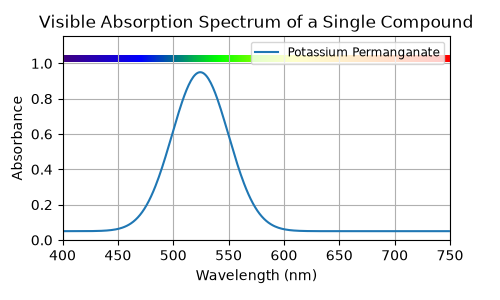

In [70]:
# CODE BLOCK 2
#
# ----------------------------------------------------------------------------------
# STUDENT INTERACTION AREA
#
# Each code block within these activities will include a standard "interaction
#   area" in which you'll read introductory information, be given the opportunity
#   to manipulate variables, and interact with the code in other ways.  In order
#   to not "break the code", please do not adjust code outside this "student
#   interaction area" unless you're sure you know what you're doing.  If you do,
#   in fact, break the code, just know that you can always re-load the original
#   file to reset everything to its ground state.
#
# ----------------------------------------------------------------------------------
#
# If this is your first time interacting with this code block, simply run the
#   code and view the results below.  Then, you may return here to change or
#   re-define the choice of compound by changing the value of the cmpd_choice
#   variable, below.  As a reminder,
#
#      1 = Tartrazine
#      2 = Copper Sulfate
#      3 = Potassium Permanganate
#      4 = Cobalt Chloride
#      5 = Nickel Sulfate
#
# Note that the variable definition below is "commented-out" (with a hashtag)
#   so that when this code block is run for the first time, the value of the
#   variable cmpd_choice is not overwritten by your choice in the previous
#   code block.  If, however, you'd like to re-define the variable within this
#   code block, you must "uncomment" it by deleting the hashtag symbol to
#   activate the line of code.  Then, once you've changed your variable
#   declaration, you can re-run this code block to observe the change in the
#   absorbance spectrum.
# One final note about "uncommenting" a line: do not add a space before the
#   variable's name.  If you do, your code will generate an error.  The start
#   of the variable's name must be the very first character of the line.
#
#cmpd_choice = "0"
#
# As before, students should ignore all code below this point.  Furthermore,
#   throughout this activity, any variables we intend for you to interact with
#   will always be defined near the top of a code block in this manner.
#
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import random

# Manage active figures before creating a new one
_manage_figures()

# Convert cmpd_choice to an integer for function input
selected_compound_id = int(cmpd_choice)

# Generate spectral data using our new function
wavelengths, absorbances, lambda_max_actual, compound_name = generate_spectrum(selected_compound_id)

fig, ax = plt.subplots(figsize=(5, 3)) # Create figure and axes explicitly
_active_figures.append(fig) # Add the new figure to the managed list

# Define visible spectrum colors and their corresponding wavelengths
# These are approximate values for a qualitative visual representation
colors = [
    (0.25, 0.0, 0.5), # Violet (~400 nm)
    (0.0, 0.0, 1.0),  # Blue (~475 nm)
    (0.0, 1.0, 0.0),  # Green (~525 nm)
    (1.0, 1.0, 0.0),  # Yellow (~570 nm)
    (1.0, 0.5, 0.0),  # Orange (~600 nm)
    (1.0, 0.0, 0.0)   # Red (~650 nm)
]

# Create a colormap from these colors
cmap_name = 'VisibleSpectrum'
cmp = mcolors.LinearSegmentedColormap.from_list(cmap_name, colors)

# Create the color bar at the top of the plot area
# The extent defines the x-range (wavelengths) and y-range (arbitrary height for the bar)
ax.imshow(
    [np.arange(400, 751)], # Data for the color bar
    cmap=cmp,
    aspect='auto',
    extent=[400, 750, ax.get_ylim()[1]*1.01, ax.get_ylim()[1]*1.05], # Use ax.get_ylim()
    interpolation='bicubic'
)

# Plot the spectrum and store the Line2D object
line, = ax.plot(wavelengths, absorbances, label=compound_name)

# Adjust y-limits to make space for the color bar
# Get current y-limits, increase the upper one to make space for the color bar
ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin, ymax * 1.1) # Extend y-axis by 10% to accommodate the color bar

ax.set_title(f'Visible Absorption Spectrum of a Single Compound')
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Absorbance')

# Create initial legend
ax.legend(fontsize='small')
ax.grid(True)

plt.subplots_adjust(bottom=0.2) # Increased bottom margin for more space

plt.show()


## Part 3: Absorption Spectra of Mixtures

Now that you've explored the individual absorption spectra of various compounds, let's investigate how their spectra combine when they are present in a mixture. In this section, you will select multiple compounds to be "on" simultaneously, and the code will generate a combined absorption spectrum, simulating what you would observe in a solution containing all selected components. This will help you understand the principle of additivity of absorbances in mixtures, a fundamental concept in spectrophotometry.

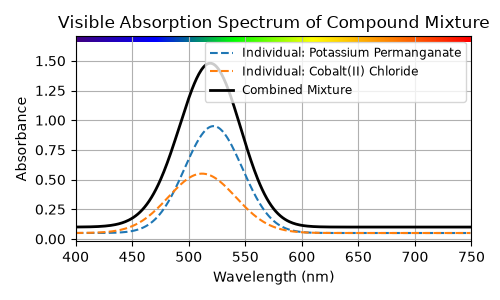

In [68]:
# CODE BLOCK 3
#
# ----------------------------------------------------------------------------------
# STUDENT INTERACTION AREA
# ----------------------------------------------------------------------------------
#
# Change the boolean (True/False) values below to include compounds in the mixture.
# Set a compound to True to include its spectrum; set to False to exclude it.
# Start with all set to False, then try changing one or more to True.
#
# SPECTRA VISIBILITY VARIABLES

tartrazine_on = False
copper_sulfate_on = False
potassium_permanganate_on = True
cobalt_chloride_on = True
nickel_sulfate_on = False

# INDIVIDUAL SPECTRA VISIBILITY
# Set to True if you want to see individual spectra plotted under the primary
# absorption line.
display_individual_spectra = False
#
# ----------------------------------------------------------------------------------
# END STUDENT INTERACTION AREA
# DO NOT EDIT CODE BELOW THIS LINE
# ----------------------------------------------------------------------------------

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# Close all previously generated plots to avoid RuntimeWarning about too many figures
plt.close('all')

# Compound IDs corresponding to the booleans
compound_selections = {
    1: tartrazine_on,
    2: copper_sulfate_on,
    3: potassium_permanganate_on,
    4: cobalt_chloride_on,
    5: nickel_sulfate_on
}

# Initialize arrays for combined spectrum
# The `generate_spectrum` function uses np.arange(400, 750, 1), so 400 to 749.
initial_wavelengths = np.arange(400, 750, 1)
combined_absorbances = np.zeros_like(initial_wavelengths, dtype=float)
active_compounds_names = []
individual_spectra_data = [] # To store (wavelengths, absorbances, compound_name) for plotting

for comp_id, is_on in compound_selections.items():
    if is_on:
        try:
            # Generate spectrum for the compound (ensure generate_spectrum is defined in a prior cell)
            wavelengths, absorbances, lambda_max, compound_name = generate_spectrum(comp_id)

            # Ensure wavelengths match for summation (should be the case if generate_spectrum is consistent)
            if not np.array_equal(wavelengths, initial_wavelengths):
                print(f"Warning: Wavelength range mismatch for {compound_name}. Skipping summation for this compound.")
                continue

            combined_absorbances += absorbances
            active_compounds_names.append(compound_name)
            individual_spectra_data.append((wavelengths, absorbances, compound_name))

        except ValueError as e:
            print(f"Error generating spectrum for compound ID {comp_id}: {e}")
            continue

if not active_compounds_names:
    print("No compounds selected. Please set at least one compound's boolean to True.")
else:
    fig, ax = plt.subplots(figsize=(5, 3)) # Create figure and axes explicitly, scaled to 50%

    # Plot individual spectra if requested and more than one compound is active
    if display_individual_spectra and len(individual_spectra_data) > 1:
        for wavelengths_ind, absorbances_ind, compound_name_ind in individual_spectra_data:
            ax.plot(wavelengths_ind, absorbances_ind, label=f'Individual: {compound_name_ind}', linestyle='--')

    # Plot the combined spectrum
    ax.plot(initial_wavelengths, combined_absorbances, label='Combined Mixture', color='black', linewidth=2)

    # Adjust y-limits to make space for the color bar *after* all plots are done
    ymin, ymax = ax.get_ylim()
    # Ensure ymax is at least 1.0 for the color bar to be visible if all absorbances are very low
    adjusted_ymax = max(ymax, 1.0) * 1.1 # Extend y-axis by 10% from either calculated max or 1.0
    ax.set_ylim(ymin, adjusted_ymax)

    # Define visible spectrum colors and their corresponding wavelengths
    colors = [
        (0.25, 0.0, 0.5), # Violet (~400 nm)
        (0.0, 0.0, 1.0),  # Blue (~475 nm)
        (0.0, 1.0, 0.0),  # Green (~525 nm)
        (1.0, 1.0, 0.0),  # Yellow (~570 nm)
        (1.0, 0.5, 0.0),  # Orange (~600 nm)
        (1.0, 0.0, 0.0)   # Red (~650 nm)
    ]
    cmap_name = 'VisibleSpectrum'
    cmp = mcolors.LinearSegmentedColormap.from_list(cmap_name, colors)

    # Create the color bar at the top of the plot area using the adjusted y-limits
    ax.imshow(
        [np.arange(400, 751)], # Data for the color bar
        cmap=cmp,
        aspect='auto',
        extent=[400, 750, ax.get_ylim()[1]*0.97, ax.get_ylim()[1]*1.00], # Place just below the very top
        interpolation='bicubic'
    )

    ax.set_title('Visible Absorption Spectrum of Compound Mixture')
    ax.set_xlabel('Wavelength (nm)')
    ax.set_ylabel('Absorbance')

    ax.legend(fontsize='small')
    ax.grid(True)
    plt.tight_layout()
    plt.show()


## Part 4: Visualizing the Effect of Concentration

Building upon our understanding of mixture spectra, this section allows you to explore the impact of *relative concentration* on the overall absorbance profile. In real-world applications, the intensity of each component's contribution to a mixture spectrum is directly proportional to its concentration.

By adjusting the `_concentration` variables in the next code block, you can simulate changing the amount of each compound in the solution. Your goal might be to:

*   **Balance peak heights:** Adjust concentrations so that all active compounds contribute approximately equally to the highest absorbance peaks.
*   **Highlight a specific compound:** Increase one compound's concentration to make its spectral features more prominent.

Experiment with different combinations and concentration values to gain an intuitive understanding of how Beer-Lambert Law principles manifest in spectroscopic mixtures.

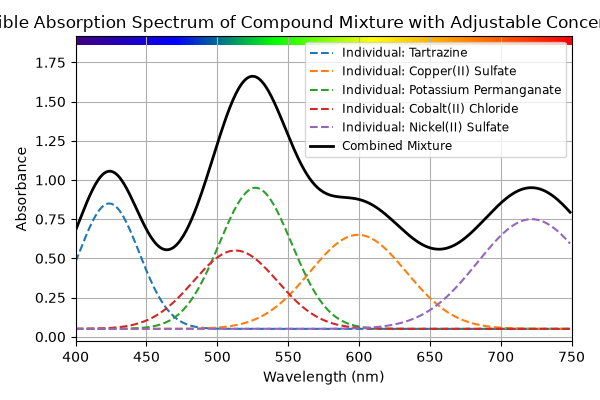

In [83]:
# ----------------------------------------------------------------------------------
# STUDENT INTERACTION AREA
# ----------------------------------------------------------------------------------
#
# To change the visibility of any of the spectra you previously worked with,
#   uncomment the compound's '_on' variable and then set the variable to True
#   (to turn on) or False (to turn off) individual absorbance spectra.
# To adjust the concentration of any compound in the simulated test sample,
#   uncomment its '_concentration' variable and change its value.  The default
#   concentrations are set to 1.0 M.  Notice that units are not included.
#
# SPECTRA VISIBILITY VARIABLES
tartrazine_on = True
copper_sulfate_on = True
potassium_permanganate_on = True
cobalt_chloride_on = True
nickel_sulfate_on = True
#
# COMPOUND CONCENTRATION VARIABLES
tartrazine_concentration = 1.0
copper_sulfate_concentration = 1.0
potassium_permanganate_concentration = 1.0
cobalt_chloride_concentration = 1.0
nickel_sulfate_concentration = 1.0
#
# INDIVIDUAL SPECTRA VISIBILITY
display_individual_spectra = True
#
# ----------------------------------------------------------------------------------
# END STUDENT INTERACTION AREA
# DO NOT EDIT CODE BELOW THIS LINE
# ----------------------------------------------------------------------------------

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# Manage active figures before creating a new one
_manage_figures()

compound_selections = {
    1: {'on': tartrazine_on, 'concentration': tartrazine_concentration},
    2: {'on': copper_sulfate_on, 'concentration': copper_sulfate_concentration},
    3: {'on': potassium_permanganate_on, 'concentration': potassium_permanganate_concentration},
    4: {'on': cobalt_chloride_on, 'concentration': cobalt_chloride_concentration},
    5: {'on': nickel_sulfate_on, 'concentration': nickel_sulfate_concentration}
}

# Initialize arrays for combined spectrum
# The `generate_spectrum` function uses np.arange(400, 750, 1), so 400 to 749.
initial_wavelengths = np.arange(400, 750, 1)
combined_absorbances = np.zeros_like(initial_wavelengths, dtype=float)
active_compounds_names = []
individual_spectra_data = [] # To store (wavelengths, absorbances, compound_name) for plotting

for comp_id, settings in compound_selections.items():
    if settings['on']:
        try:
            # generate_spectrum is defined in cell Sb1ulVyqT85b
            wavelengths, absorbances, lambda_max, compound_name = generate_spectrum(comp_id)

            # Ensure wavelengths match for summation (should be the case if generate_spectrum is consistent)
            if not np.array_equal(wavelengths, initial_wavelengths):
                print(f"Warning: Wavelength range mismatch for {compound_name}. Skipping summation for this compound.")
                continue

            # Apply the concentration factor here
            scaled_absorbances = absorbances * settings['concentration']
            combined_absorbances += scaled_absorbances
            active_compounds_names.append(compound_name)
            individual_spectra_data.append((wavelengths, scaled_absorbances, compound_name))

        except ValueError as e:
            print(f"Error generating spectrum for compound ID {comp_id}: {e}")
            continue

if not active_compounds_names:
    print("No compounds selected. Please uncomment and set at least one compound's '_on' variable to True.")
else:
    fig, ax = plt.subplots(figsize=(6, 4))
    _active_figures.append(fig) # Add the new figure to the managed list

    # Plot individual spectra if requested and more than one compound is active
    if display_individual_spectra and len(individual_spectra_data) > 1:
        for wavelengths_ind, absorbances_ind, compound_name_ind in individual_spectra_data:
            ax.plot(wavelengths_ind, absorbances_ind, label=f'Individual: {compound_name_ind}', linestyle='--')

    # Plot the combined spectrum
    ax.plot(initial_wavelengths, combined_absorbances, label='Combined Mixture', color='black', linewidth=2)

    # Adjust y-limits to make space for the color bar *after* all plots are done
    ymin, ymax = ax.get_ylim()
    # Ensure ymax is at least 1.0 for the color bar to be visible if all absorbances are very low
    adjusted_ymax = max(ymax, 1.0) * 1.1 # Extend y-axis by 10% from either calculated max or 1.0
    ax.set_ylim(ymin, adjusted_ymax)

    # Define visible spectrum colors and their corresponding wavelengths
    colors = [
        (0.25, 0.0, 0.5), # Violet (~400 nm)
        (0.0, 0.0, 1.0),  # Blue (~475 nm)
        (0.0, 1.0, 0.0),  # Green (~525 nm)
        (1.0, 1.0, 0.0),  # Yellow (~570 nm)
        (1.0, 0.5, 0.0),  # Orange (~600 nm)
        (1.0, 0.0, 0.0)   # Red (~650 nm)
    ]
    cmap_name = 'VisibleSpectrum'
    cmp = mcolors.LinearSegmentedColormap.from_list(cmap_name, colors)

    # Create the color bar at the top of the plot area using the adjusted y-limits
    ax.imshow(
        [np.arange(400, 751)], # Data for the color bar
        cmap=cmp,
        aspect='auto',
        extent=[400, 750, ax.get_ylim()[1]*0.97, ax.get_ylim()[1]*1.00], # Place just below the very top
        interpolation='bicubic'
    )

    ax.set_title('Visible Absorption Spectrum of Compound Mixture with Adjustable Concentrations')
    ax.set_xlabel('Wavelength (nm)')
    ax.set_ylabel('Absorbance')

    ax.legend(fontsize='small')
    ax.grid(True)
    plt.tight_layout()
    plt.show()
